# 04 — Gap boundary detection (paired boundaries)

Nuevo enfoque para sustituir Hough como salida principal.

En vez de forzar los cortes a líneas rectas, este notebook detecta **zonas de hueco** entre piezas de goma y extrae sus **dos bordes enfrentados**. Esto permite conservar bordes irregulares o ligeramente curvos y medir el hueco en varios puntos.

Flujo:

```text
rectified grayscale image + approximate rubber mask
        ↓
background pixels with rubber support on both sides
        ↓
vertical/horizontal gap candidates
        ↓
boundary pair extraction
        ↓
10 distance measurements per gap
```

Entradas:
- `outputs/02_rectified_clean/` — imágenes rectificadas.
- `outputs/03_canny/` — edge maps de Canny, usados sobre todo como apoyo/debug.
- `outputs/02_rectified_clean/calibration.json` — calibración.

Salidas:
- `outputs/04_gap_boundaries/gap_boundaries.json`
- imágenes debug en `outputs/04_gap_boundaries/debug/`


In [4]:
from pathlib import Path
import json
import math

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded")


Libraries loaded


In [5]:
# ── Paths ──────────────────────────────────────────────────────────────────
RECTIFIED_DIR = Path("outputs/02_rectified")
CANNY_DIR = Path("outputs/03_canny")
CALIB_PATH = RECTIFIED_DIR / "calibration.json"

OUTPUT_DIR = Path("outputs/04_gap_boundaries")
DEBUG_DIR = OUTPUT_DIR / "debug"

MASK_DEBUG_DIR = DEBUG_DIR / "gap_masks"
OVERLAY_DEBUG_DIR = DEBUG_DIR / "gap_overlays"
STEPS_DEBUG_DIR = DEBUG_DIR / "steps_overview"

for d in [OUTPUT_DIR, DEBUG_DIR, MASK_DEBUG_DIR, OVERLAY_DEBUG_DIR, STEPS_DEBUG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Metric reference ───────────────────────────────────────────────────────
# Rectified images are expected to represent the 800 mm QR reference square.
QR_LEG_MM = 800.0

# ── Thresholding parameters ────────────────────────────────────────────────
# Otsu separates dark rubber from bright table.
# The background threshold is intentionally lower to include shadowed gap pixels.
RUBBER_THR_FACTOR = 1.00
BACKGROUND_THR_FACTOR = 0.65

# ── Gap detection parameters ───────────────────────────────────────────────
# A vertical gap pixel must have rubber close on its left and right.
# A horizontal gap pixel must have rubber close above and below.
SIDE_SUPPORT_RADIUS = 45
MIN_SIDE_SUPPORT = 4

# Candidate filtering.
MIN_GAP_LENGTH = 55          # long dimension: height for vertical, width for horizontal
MIN_GAP_THICKNESS = 2        # short dimension
MAX_GAP_THICKNESS = 85       # avoids selecting the large empty space between rows
MIN_GAP_AREA = 35
BORDER_MARGIN = 8            # remove components too close to image border

# Morphology to connect fragmented gap pixels in the main direction.
VERTICAL_CLOSE_KERNEL = (3, 21)
HORIZONTAL_CLOSE_KERNEL = (21, 3)
OPEN_KERNEL = (3, 3)

# Boundary extraction and measurements.
BOUNDARY_SMOOTH_K = 7
N_SAMPLES_PER_GAP = 10
MAX_GAPS_PER_IMAGE = 12

# Optional: if True, overlays Canny edges as faint blue reference.
SHOW_CANNY_IN_OVERLAY = True

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

print(f"Rectified dir: {RECTIFIED_DIR.resolve()}")
print(f"Canny dir    : {CANNY_DIR.resolve()}")
print(f"Output dir   : {OUTPUT_DIR.resolve()}")


Rectified dir: C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified
Canny dir    : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\03_canny
Output dir   : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\04_gap_boundaries


In [6]:
# Load calibration if available.
if CALIB_PATH.exists():
    with open(CALIB_PATH, "r", encoding="utf-8") as f:
        calibration_data = json.load(f)

    if isinstance(calibration_data, list):
        calibration_by_name = {item["image_name"]: item for item in calibration_data}
    elif isinstance(calibration_data, dict):
        calibration_by_name = calibration_data
    else:
        calibration_by_name = {}

    print(f"Calibration records loaded: {len(calibration_by_name)}")
else:
    calibration_by_name = {}
    print("[WARN] calibration.json not found. Measurements will assume 800 px = 800 mm.")


image_paths = sorted([
    p for p in RECTIFIED_DIR.iterdir()
    if p.suffix.lower() in VALID_EXTENSIONS
    and p.name.startswith("Multimedia_")
])

print(f"Found {len(image_paths)} rectified images")


Calibration records loaded: 20
Found 20 rectified images


## Utility functions

In [7]:
def read_gray(path: Path) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return img


def read_edges(image_name: str, shape: tuple[int, int]) -> np.ndarray:
    path = CANNY_DIR / image_name
    edges = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if edges is None:
        return np.zeros(shape, dtype=np.uint8)

    if edges.shape[:2] != shape:
        edges = cv2.resize(edges, (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST)

    return edges


def px_per_mm_for_image(image_name: str, img_shape: tuple[int, int]) -> float:
    """
    Estimate px/mm in rectified coordinates.
    In the clean rectification notebook, images are expected to be close to 800x800.
    """
    h, w = img_shape[:2]

    # Prefer explicit value if the calibration file contains one.
    calib = calibration_by_name.get(image_name, {})
    for key in ["rectified_px_per_mm", "px_per_mm"]:
        if key in calib:
            try:
                val = float(calib[key])
                if val > 0:
                    return val
            except Exception:
                pass

    return min(h, w) / QR_LEG_MM


def smooth_1d(values: np.ndarray, k: int = BOUNDARY_SMOOTH_K) -> np.ndarray:
    values = np.asarray(values, dtype=np.float32)

    if k <= 1 or len(values) < k:
        return values

    if k % 2 == 0:
        k += 1

    pad = k // 2
    padded = np.pad(values, (pad, pad), mode="edge")
    kernel = np.ones(k, dtype=np.float32) / k

    return np.convolve(padded, kernel, mode="valid")


def color_for_id(idx: int) -> tuple[int, int, int]:
    palette = [
        (0, 255, 255),    # yellow
        (0, 165, 255),    # orange
        (255, 255, 0),    # cyan
        (0, 255, 0),      # green
        (255, 0, 255),    # magenta
        (255, 0, 0),      # blue
        (0, 0, 255),      # red
    ]
    return palette[idx % len(palette)]


## Build approximate rubber/background masks

The mask is **not** the final cut detector. It is only used to determine whether a bright region is located between rubber areas.


In [8]:
def build_basic_masks(img_gray: np.ndarray) -> dict:
    """
    Build approximate rubber and background masks.

    - rubber_mask: dark regions
    - background_mask: bright / table / gap regions

    The background threshold is lower than pure Otsu to preserve shadowed gaps.
    """
    thr_otsu, _ = cv2.threshold(
        img_gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    rubber_thr = float(thr_otsu * RUBBER_THR_FACTOR)
    background_thr = float(thr_otsu * BACKGROUND_THR_FACTOR)

    rubber_mask = (img_gray < rubber_thr).astype(np.uint8) * 255
    background_mask = (img_gray > background_thr).astype(np.uint8) * 255

    return {
        "thr_otsu": float(thr_otsu),
        "rubber_thr": rubber_thr,
        "background_thr": background_thr,
        "rubber_mask": rubber_mask,
        "background_mask": background_mask,
    }


## Side-support gap masks

A candidate gap should be a bright/background region with rubber on **both sides**.

For vertical cuts:
- rubber on the left and rubber on the right.

For horizontal cuts:
- rubber above and rubber below.


In [9]:
def horizontal_side_support(mask: np.ndarray, radius: int) -> tuple[np.ndarray, np.ndarray]:
    """
    For every pixel, count rubber pixels within `radius` on the left and right.
    """
    m = (mask > 0).astype(np.uint8)
    h, w = m.shape

    csum = np.cumsum(m, axis=1)
    csum = np.pad(csum, ((0, 0), (1, 0)), mode="constant", constant_values=0)

    xs = np.arange(w)

    left_start = np.maximum(0, xs - radius)
    left_end = xs

    right_start = np.minimum(w, xs + 1)
    right_end = np.minimum(w, xs + radius + 1)

    left_count = csum[:, left_end] - csum[:, left_start]
    right_count = csum[:, right_end] - csum[:, right_start]

    return left_count, right_count


def vertical_side_support(mask: np.ndarray, radius: int) -> tuple[np.ndarray, np.ndarray]:
    """
    For every pixel, count rubber pixels within `radius` above and below.
    """
    m = (mask > 0).astype(np.uint8)
    h, w = m.shape

    csum = np.cumsum(m, axis=0)
    csum = np.pad(csum, ((1, 0), (0, 0)), mode="constant", constant_values=0)

    ys = np.arange(h)

    up_start = np.maximum(0, ys - radius)
    up_end = ys

    down_start = np.minimum(h, ys + 1)
    down_end = np.minimum(h, ys + radius + 1)

    up_count = csum[up_end, :] - csum[up_start, :]
    down_count = csum[down_end, :] - csum[down_start, :]

    return up_count, down_count


def build_gap_masks(img_gray: np.ndarray) -> dict:
    masks = build_basic_masks(img_gray)

    rubber = masks["rubber_mask"]
    background = masks["background_mask"] > 0

    left_count, right_count = horizontal_side_support(rubber, SIDE_SUPPORT_RADIUS)
    up_count, down_count = vertical_side_support(rubber, SIDE_SUPPORT_RADIUS)

    vertical_gap = (
        background
        & (left_count >= MIN_SIDE_SUPPORT)
        & (right_count >= MIN_SIDE_SUPPORT)
    ).astype(np.uint8) * 255

    horizontal_gap = (
        background
        & (up_count >= MIN_SIDE_SUPPORT)
        & (down_count >= MIN_SIDE_SUPPORT)
    ).astype(np.uint8) * 255

    # Connect fragmented regions along the expected direction.
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, VERTICAL_CLOSE_KERNEL)
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, HORIZONTAL_CLOSE_KERNEL)
    open_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, OPEN_KERNEL)

    vertical_gap_clean = cv2.morphologyEx(vertical_gap, cv2.MORPH_CLOSE, v_kernel)
    vertical_gap_clean = cv2.morphologyEx(vertical_gap_clean, cv2.MORPH_OPEN, open_kernel)

    horizontal_gap_clean = cv2.morphologyEx(horizontal_gap, cv2.MORPH_CLOSE, h_kernel)
    horizontal_gap_clean = cv2.morphologyEx(horizontal_gap_clean, cv2.MORPH_OPEN, open_kernel)

    masks.update({
        "vertical_gap_raw": vertical_gap,
        "horizontal_gap_raw": horizontal_gap,
        "vertical_gap": vertical_gap_clean,
        "horizontal_gap": horizontal_gap_clean,
    })

    return masks


## Gap component extraction and boundary pair modelling

In [10]:
def extract_boundary_pair(comp_mask: np.ndarray, orientation: str) -> dict | None:
    """
    Extract two opposed boundaries from a connected gap component.

    For vertical gaps:
      left boundary  = min x per row
      right boundary = max x per row

    For horizontal gaps:
      top boundary    = min y per column
      bottom boundary = max y per column
    """
    comp = comp_mask > 0

    if orientation == "vertical":
        ys = np.where(np.any(comp, axis=1))[0]

        if len(ys) < 2:
            return None

        left_x = []
        right_x = []
        valid_y = []

        for y in ys:
            xs = np.where(comp[y, :])[0]

            if len(xs) == 0:
                continue

            valid_y.append(y)
            left_x.append(xs.min())
            right_x.append(xs.max())

        if len(valid_y) < 2:
            return None

        valid_y = np.asarray(valid_y, dtype=np.float32)
        left_x = smooth_1d(np.asarray(left_x, dtype=np.float32))
        right_x = smooth_1d(np.asarray(right_x, dtype=np.float32))

        widths = right_x - left_x

        return {
            "axis": valid_y.tolist(),
            "left_x": left_x.tolist(),
            "right_x": right_x.tolist(),
            "widths_px": widths.tolist(),
        }

    if orientation == "horizontal":
        xs = np.where(np.any(comp, axis=0))[0]

        if len(xs) < 2:
            return None

        top_y = []
        bottom_y = []
        valid_x = []

        for x in xs:
            ys = np.where(comp[:, x])[0]

            if len(ys) == 0:
                continue

            valid_x.append(x)
            top_y.append(ys.min())
            bottom_y.append(ys.max())

        if len(valid_x) < 2:
            return None

        valid_x = np.asarray(valid_x, dtype=np.float32)
        top_y = smooth_1d(np.asarray(top_y, dtype=np.float32))
        bottom_y = smooth_1d(np.asarray(bottom_y, dtype=np.float32))

        widths = bottom_y - top_y

        return {
            "axis": valid_x.tolist(),
            "top_y": top_y.tolist(),
            "bottom_y": bottom_y.tolist(),
            "widths_px": widths.tolist(),
        }

    raise ValueError(f"Unknown orientation: {orientation}")


def extract_component_candidates(gap_mask: np.ndarray, orientation: str) -> list[dict]:
    """
    Extract connected components from a vertical/horizontal gap mask.
    """
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        (gap_mask > 0).astype(np.uint8),
        connectivity=8
    )

    h_img, w_img = gap_mask.shape[:2]
    candidates = []

    for label_id in range(1, num_labels):
        x, y, w, h, area = stats[label_id]

        if area < MIN_GAP_AREA:
            continue

        if x <= BORDER_MARGIN or y <= BORDER_MARGIN:
            continue

        if x + w >= w_img - BORDER_MARGIN or y + h >= h_img - BORDER_MARGIN:
            continue

        if orientation == "vertical":
            length = h
            thickness = w
        elif orientation == "horizontal":
            length = w
            thickness = h
        else:
            raise ValueError(f"Unknown orientation: {orientation}")

        if length < MIN_GAP_LENGTH:
            continue

        if thickness < MIN_GAP_THICKNESS or thickness > MAX_GAP_THICKNESS:
            continue

        comp_mask = (labels == label_id).astype(np.uint8) * 255

        boundary = extract_boundary_pair(comp_mask, orientation)

        if boundary is None:
            continue

        mean_width_px = float(np.mean(boundary["widths_px"]))

        # Keep plausible gaps only.
        if mean_width_px < MIN_GAP_THICKNESS or mean_width_px > MAX_GAP_THICKNESS:
            continue

        score = float(length * 2.0 + area * 0.05 - mean_width_px * 1.5)

        candidates.append({
            "orientation": orientation,
            "bbox": [int(x), int(y), int(w), int(h)],
            "area": int(area),
            "length": int(length),
            "thickness": int(thickness),
            "mean_width_px": mean_width_px,
            "score": score,
            "component_mask": comp_mask,
            "boundary": boundary,
        })

    candidates.sort(key=lambda c: c["score"], reverse=True)

    return candidates


In [11]:
def sample_gap(candidate: dict, px_per_mm: float, n_samples: int = N_SAMPLES_PER_GAP) -> list[dict]:
    """
    Sample distances between the two opposed boundaries of a gap.
    """
    orientation = candidate["orientation"]
    boundary = candidate["boundary"]

    axis = np.asarray(boundary["axis"], dtype=np.float32)

    if len(axis) == 0:
        return []

    sample_axis = np.linspace(axis.min(), axis.max(), n_samples)

    samples = []

    if orientation == "vertical":
        left_x = np.asarray(boundary["left_x"], dtype=np.float32)
        right_x = np.asarray(boundary["right_x"], dtype=np.float32)

        sample_left_x = np.interp(sample_axis, axis, left_x)
        sample_right_x = np.interp(sample_axis, axis, right_x)

        for i, (y, xl, xr) in enumerate(zip(sample_axis, sample_left_x, sample_right_x)):
            dist_px = float(abs(xr - xl))
            samples.append({
                "sample_id": i,
                "orientation": orientation,
                "point_a_px": [float(xl), float(y)],
                "point_b_px": [float(xr), float(y)],
                "distance_px": dist_px,
                "distance_mm": dist_px / px_per_mm,
            })

    elif orientation == "horizontal":
        top_y = np.asarray(boundary["top_y"], dtype=np.float32)
        bottom_y = np.asarray(boundary["bottom_y"], dtype=np.float32)

        sample_top_y = np.interp(sample_axis, axis, top_y)
        sample_bottom_y = np.interp(sample_axis, axis, bottom_y)

        for i, (x, yt, yb) in enumerate(zip(sample_axis, sample_top_y, sample_bottom_y)):
            dist_px = float(abs(yb - yt))
            samples.append({
                "sample_id": i,
                "orientation": orientation,
                "point_a_px": [float(x), float(yt)],
                "point_b_px": [float(x), float(yb)],
                "distance_px": dist_px,
                "distance_mm": dist_px / px_per_mm,
            })

    else:
        raise ValueError(f"Unknown orientation: {orientation}")

    return samples


## Debug visualization

In [12]:
def draw_gap_candidate(
    overlay: np.ndarray,
    candidate: dict,
    gap_id: int,
    px_per_mm: float,
    draw_samples: bool = True
) -> None:
    """
    Draw a candidate gap as paired boundaries plus sampled measurements.
    """
    color = color_for_id(gap_id)
    orientation = candidate["orientation"]
    boundary = candidate["boundary"]
    x, y, w, h = candidate["bbox"]

    cv2.rectangle(overlay, (x, y), (x + w, y + h), color, 2)

    label = f"{gap_id}:{orientation[0]} {candidate['mean_width_px']/px_per_mm:.1f}mm"
    cv2.putText(
        overlay,
        label,
        (x, max(20, y - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        1,
        cv2.LINE_AA
    )

    if orientation == "vertical":
        axis = np.asarray(boundary["axis"], dtype=np.float32)
        left_x = np.asarray(boundary["left_x"], dtype=np.float32)
        right_x = np.asarray(boundary["right_x"], dtype=np.float32)

        left_pts = np.stack([left_x, axis], axis=1).astype(np.int32)
        right_pts = np.stack([right_x, axis], axis=1).astype(np.int32)

        if len(left_pts) >= 2:
            cv2.polylines(overlay, [left_pts], False, (255, 255, 0), 2)
        if len(right_pts) >= 2:
            cv2.polylines(overlay, [right_pts], False, (0, 165, 255), 2)

    else:
        axis = np.asarray(boundary["axis"], dtype=np.float32)
        top_y = np.asarray(boundary["top_y"], dtype=np.float32)
        bottom_y = np.asarray(boundary["bottom_y"], dtype=np.float32)

        top_pts = np.stack([axis, top_y], axis=1).astype(np.int32)
        bottom_pts = np.stack([axis, bottom_y], axis=1).astype(np.int32)

        if len(top_pts) >= 2:
            cv2.polylines(overlay, [top_pts], False, (255, 255, 0), 2)
        if len(bottom_pts) >= 2:
            cv2.polylines(overlay, [bottom_pts], False, (0, 165, 255), 2)

    if draw_samples:
        samples = sample_gap(candidate, px_per_mm)

        for sample in samples:
            p1 = tuple(np.round(sample["point_a_px"]).astype(int))
            p2 = tuple(np.round(sample["point_b_px"]).astype(int))

            cv2.circle(overlay, p1, 3, (0, 255, 255), -1)
            cv2.circle(overlay, p2, 3, (0, 255, 255), -1)
            cv2.line(overlay, p1, p2, (0, 255, 255), 1)


def create_debug_overlay(
    img_gray: np.ndarray,
    edges: np.ndarray,
    candidates: list[dict],
    px_per_mm: float
) -> np.ndarray:
    overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

    if SHOW_CANNY_IN_OVERLAY and edges is not None:
        overlay[edges > 0] = (180, 80, 0)  # faint reference

    for idx, cand in enumerate(candidates):
        draw_gap_candidate(overlay, cand, idx, px_per_mm)

    return overlay


def save_steps_overview(
    image_name: str,
    img_gray: np.ndarray,
    edges: np.ndarray,
    masks: dict,
    candidates: list[dict],
    px_per_mm: float
) -> None:
    overlay = create_debug_overlay(img_gray, edges, candidates, px_per_mm)

    stem = Path(image_name).stem

    # Save individual debug masks.
    cv2.imwrite(str(MASK_DEBUG_DIR / f"{stem}_rubber_mask.png"), masks["rubber_mask"])
    cv2.imwrite(str(MASK_DEBUG_DIR / f"{stem}_background_mask.png"), masks["background_mask"])
    cv2.imwrite(str(MASK_DEBUG_DIR / f"{stem}_vertical_gap.png"), masks["vertical_gap"])
    cv2.imwrite(str(MASK_DEBUG_DIR / f"{stem}_horizontal_gap.png"), masks["horizontal_gap"])
    cv2.imwrite(str(OVERLAY_DEBUG_DIR / f"{stem}_gap_overlay.png"), overlay)

    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    fig.suptitle(
        f"{image_name} | gaps={len(candidates)} | "
        f"Otsu={masks['thr_otsu']:.1f} | bg_thr={masks['background_thr']:.1f}",
        fontsize=12
    )

    axes[0].imshow(img_gray, cmap="gray")
    axes[0].set_title("Rectified image")
    axes[0].axis("off")

    axes[1].imshow(edges, cmap="gray")
    axes[1].set_title("Canny edges")
    axes[1].axis("off")

    axes[2].imshow(masks["vertical_gap"], cmap="gray")
    axes[2].set_title("Vertical gap mask")
    axes[2].axis("off")

    axes[3].imshow(masks["horizontal_gap"], cmap="gray")
    axes[3].set_title("Horizontal gap mask")
    axes[3].axis("off")

    axes[4].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[4].set_title("Paired boundaries + samples")
    axes[4].axis("off")

    plt.tight_layout()
    plt.savefig(STEPS_DEBUG_DIR / f"{stem}_steps.png", dpi=130)
    plt.close()


## Processing pipeline

In [13]:
def serialize_candidate(candidate: dict, px_per_mm: float, gap_id: int) -> dict:
    """
    Convert a candidate into JSON-serializable output.
    """
    samples = sample_gap(candidate, px_per_mm)

    mean_distance_mm = float(np.mean([s["distance_mm"] for s in samples])) if samples else None
    std_distance_mm = float(np.std([s["distance_mm"] for s in samples])) if samples else None

    return {
        "gap_id": gap_id,
        "orientation": candidate["orientation"],
        "bbox_px": candidate["bbox"],
        "area_px": candidate["area"],
        "length_px": candidate["length"],
        "thickness_px": candidate["thickness"],
        "mean_width_px": candidate["mean_width_px"],
        "mean_width_mm": candidate["mean_width_px"] / px_per_mm,
        "mean_sample_distance_mm": mean_distance_mm,
        "std_sample_distance_mm": std_distance_mm,
        "score": candidate["score"],
        "samples": samples,
    }


def process_image(image_path: Path) -> dict | None:
    image_name = image_path.name
    img_gray = read_gray(image_path)
    edges = read_edges(image_name, img_gray.shape)

    px_per_mm = px_per_mm_for_image(image_name, img_gray.shape)

    masks = build_gap_masks(img_gray)

    vertical_candidates = extract_component_candidates(
        masks["vertical_gap"],
        orientation="vertical"
    )

    horizontal_candidates = extract_component_candidates(
        masks["horizontal_gap"],
        orientation="horizontal"
    )

    all_candidates = vertical_candidates + horizontal_candidates
    all_candidates = sorted(all_candidates, key=lambda c: c["score"], reverse=True)
    all_candidates = all_candidates[:MAX_GAPS_PER_IMAGE]

    save_steps_overview(
        image_name=image_name,
        img_gray=img_gray,
        edges=edges,
        masks=masks,
        candidates=all_candidates,
        px_per_mm=px_per_mm
    )

    gaps_json = [
        serialize_candidate(candidate, px_per_mm, gap_id=i)
        for i, candidate in enumerate(all_candidates)
    ]

    return {
        "image_name": image_name,
        "px_per_mm": float(px_per_mm),
        "thresholds": {
            "otsu": masks["thr_otsu"],
            "rubber_thr": masks["rubber_thr"],
            "background_thr": masks["background_thr"],
        },
        "num_vertical_candidates": len(vertical_candidates),
        "num_horizontal_candidates": len(horizontal_candidates),
        "num_selected_gaps": len(gaps_json),
        "gaps": gaps_json,
    }


In [14]:
results = []

for path in image_paths:
    print(f"Processing {path.name}...")
    result = process_image(path)

    if result is not None:
        results.append(result)

out_json = OUTPUT_DIR / "gap_boundaries.json"

with open(out_json, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print(f"\nProcessed images: {len(results)}")
print(f"Saved results to: {out_json.resolve()}")


Processing Multimedia_31.jpg...
Processing Multimedia_32.jpg...
Processing Multimedia_33.jpg...
Processing Multimedia_34.jpg...
Processing Multimedia_35.jpg...
Processing Multimedia_36.jpg...
Processing Multimedia_37.jpg...
Processing Multimedia_39.jpg...
Processing Multimedia_40.jpg...
Processing Multimedia_41.jpg...
Processing Multimedia_42.jpg...
Processing Multimedia_43.jpg...
Processing Multimedia_45.jpg...
Processing Multimedia_46.jpg...
Processing Multimedia_47.jpg...
Processing Multimedia_48.jpg...
Processing Multimedia_49.jpg...
Processing Multimedia_50.jpg...
Processing Multimedia_51.jpg...
Processing Multimedia_52.jpg...

Processed images: 20
Saved results to: C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\04_gap_boundaries\gap_boundaries.json


## Quick inspection

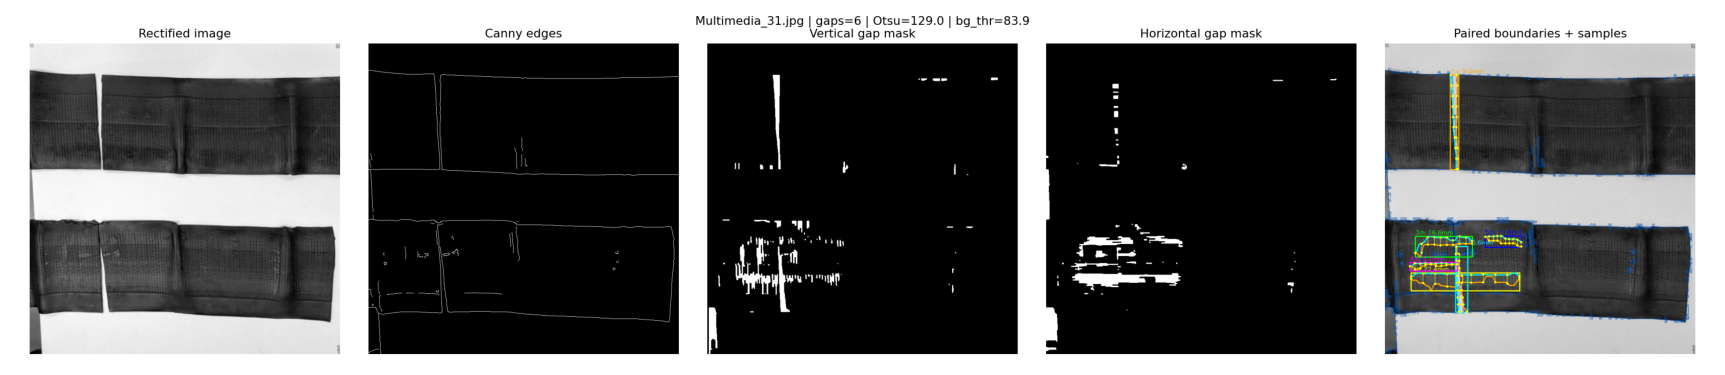

In [15]:
def visualize_result(image_name: str):
    """
    Display the saved debug overview for one image.
    """
    stem = Path(image_name).stem
    overview_path = STEPS_DEBUG_DIR / f"{stem}_steps.png"

    if not overview_path.exists():
        print(f"Missing overview: {overview_path}")
        return

    img = cv2.imread(str(overview_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(22, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


if len(image_paths) > 0:
    visualize_result(image_paths[0].name)


In [16]:
# Summary table
summary = []

for item in results:
    distances = []
    for gap in item["gaps"]:
        if gap["mean_sample_distance_mm"] is not None:
            distances.append(gap["mean_sample_distance_mm"])

    summary.append({
        "image_name": item["image_name"],
        "selected_gaps": item["num_selected_gaps"],
        "vertical_candidates": item["num_vertical_candidates"],
        "horizontal_candidates": item["num_horizontal_candidates"],
        "mean_gap_distance_mm": float(np.mean(distances)) if distances else None,
    })

summary[:5]


[{'image_name': 'Multimedia_31.jpg',
  'selected_gaps': 6,
  'vertical_candidates': 2,
  'horizontal_candidates': 4,
  'mean_gap_distance_mm': 12.050802557806795},
 {'image_name': 'Multimedia_32.jpg',
  'selected_gaps': 7,
  'vertical_candidates': 4,
  'horizontal_candidates': 3,
  'mean_gap_distance_mm': 11.83469919132601},
 {'image_name': 'Multimedia_33.jpg',
  'selected_gaps': 5,
  'vertical_candidates': 3,
  'horizontal_candidates': 2,
  'mean_gap_distance_mm': 14.065078263059258},
 {'image_name': 'Multimedia_34.jpg',
  'selected_gaps': 8,
  'vertical_candidates': 4,
  'horizontal_candidates': 4,
  'mean_gap_distance_mm': 16.536516621772897},
 {'image_name': 'Multimedia_35.jpg',
  'selected_gaps': 4,
  'vertical_candidates': 1,
  'horizontal_candidates': 3,
  'mean_gap_distance_mm': 14.353180924709886}]